# Importing file

In [16]:
import pandas as pd
df = pd.read_csv("../data/Crypto_historical_data.csv", parse_dates=["Date"], index_col="Date")
df.head()
df['ticker'].value_counts() 


ticker
WETH-USD         17076
USDT-USD          5826
DOGE-USD          5826
USDC-USD          5160
WBTC-USD          4932
                 ...  
2Z-USD              29
USDAI-USD           28
USDT0-USD           28
SYRUPUSDC-USD       15
OUSG-USD             8
Name: count, Length: 213, dtype: int64

# selecting Bitcoin fron 250 coins

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

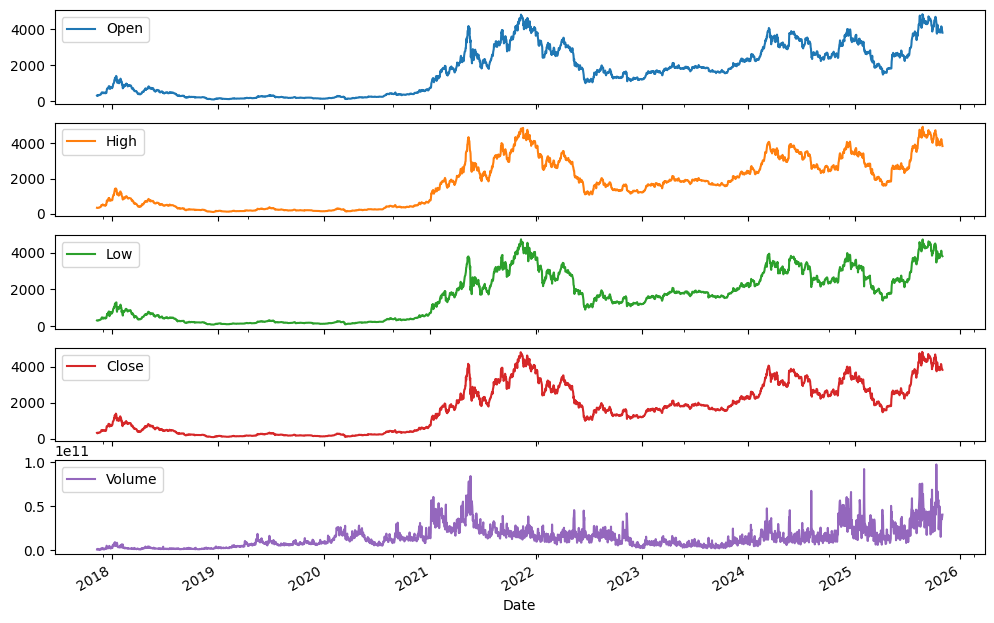

In [30]:
coin = "ETH-USD"
coin_df = df[df['ticker']==coin].sort_index()
coin_df = coin_df[['Open','High','Low','Close','Volume']].dropna()
coin_df.plot(subplots=True, figsize=(12,8))


# Preprocessing the data and feature scaling

In [31]:
import numpy as np
def create_features(df, lags=[1,2,3,5,10], windows=[3,7,14]):
    X = pd.DataFrame(index=df.index)
    X['close'] = df['Close']
    X['log_ret'] = np.log(df['Close']).diff()
    for l in lags:
        X[f'lag_{l}'] = df['Close'].shift(l)
    for w in windows:
        X[f'rolling_mean_{w}'] = df['Close'].rolling(w).mean()
        X[f'rolling_std_{w}'] = df['Close'].rolling(w).std()
        X[f'rolling_max_{w}'] = df['Close'].rolling(w).max()
    X['vol_mean_7'] = df['Volume'].rolling(7).mean()
    X = X.dropna()
    return X


In [32]:
X = create_features(coin_df)
y = coin_df['Close'].shift(-1).loc[X.index] 
X = X.iloc[:-1]
y = y.iloc[:-1]


# Splitting data for training

In [33]:
n = len(X)
train_end = int(n*0.8)
X_train, X_val = X.iloc[:train_end], X.iloc[train_end:]
y_train, y_val = y.iloc[:train_end], y.iloc[train_end:]


In [34]:
y_pred_naive = X_val['lag_1']  # predict yesterday's close
from sklearn.metrics import mean_absolute_error
print("Naive MAE:", mean_absolute_error(y_val, y_pred_naive))


Naive MAE: 115.2428917194235


# Random forest

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
print("MAE:", mean_absolute_error(y_val, y_pred))

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE:", rmse)


MAE: 97.34973925118364
RMSE: 132.776376080163


# XGBOOST

In [36]:
import xgboost as xgb
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
params = {"objective":"reg:squarederror", "learning_rate":0.05, "max_depth":6, "seed":42}
bst = xgb.train(params, dtrain, num_boost_round=1000, evals=[(dval,"val")], early_stopping_rounds=50, verbose_eval=50)
y_pred_xgb = bst.predict(dval)


[0]	val-rmse:1825.62191
[50]	val-rmse:219.56995
[100]	val-rmse:147.02157
[150]	val-rmse:145.31143
[192]	val-rmse:145.81914


# LSTM (sequence model) Trial

In [37]:
import numpy as np
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  

seq_len = 30  
def make_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(len(X_arr) - seq_len):
        Xs.append(X_arr[i:i+seq_len])
        ys.append(y_arr[i+seq_len])
    return np.array(Xs), np.array(ys)

X_arr = X_scaled
y_arr = y.values
X_seq, y_seq = make_sequences(X_arr, y_arr, seq_len)

# train/val split
split = int(len(X_seq)*0.8)
X_tr, X_va = X_seq[:split], X_seq[split:]
y_tr, y_va = y_seq[:split], y_seq[split:]

# build LSTM
import tensorflow as tf
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Input(shape=(seq_len, X_tr.shape[2])),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=50, batch_size=64)


Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 3079857.0000 - mae: 1321.2269 - val_loss: 9954587.0000 - val_mae: 3061.9983
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3066167.5000 - mae: 1315.3411 - val_loss: 9937831.0000 - val_mae: 3059.2539
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3061010.5000 - mae: 1313.2570 - val_loss: 9928694.0000 - val_mae: 3057.7603
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3057260.2500 - mae: 1311.8130 - val_loss: 9920051.0000 - val_mae: 3056.3467
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3053647.0000 - mae: 1310.4316 - val_loss: 9911819.0000 - val_mae: 3054.9995
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3050174.7500 - mae: 1309.1124 - val_loss: 9903894.0000 - val_mae: 3053.7026
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3046805.7500 - mae: 1307.8231 - val_loss: 9896121.0000 - val_mae: 3052.4294
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - lo

# Evaluating all the models (MAE, RMSE, R²)

1. Naive baseline
2. Random Forest
3. XGBoost
4. LSTM

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Naive baseline ---
mae_naive = mean_absolute_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_val, y_pred_naive))
r2_naive = r2_score(y_val, y_pred_naive)

# --- 2. Random Forest ---
mae_rf = mean_absolute_error(y_val, y_pred)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred))
r2_rf = r2_score(y_val, y_pred)

# --- 3. XGBoost ---
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
r2_xgb = r2_score(y_val, y_pred_xgb)

# --- 4. LSTM ---
y_pred_lstm = model.predict(X_va)
mae_lstm = mean_absolute_error(y_va, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_va, y_pred_lstm))
r2_lstm = r2_score(y_va, y_pred_lstm)

# --- Summary table ---
results = pd.DataFrame({
    'Model': ['Naive', 'Random Forest', 'XGBoost', 'LSTM'],
    'MAE': [mae_naive, mae_rf, mae_xgb, mae_lstm],
    'RMSE': [rmse_naive, rmse_rf, rmse_xgb, rmse_lstm],
    'R²': [r2_naive, r2_rf, r2_xgb, r2_lstm]
})
print(results)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
           Model          MAE         RMSE         R²
0          Naive   115.242892   161.002019   0.954866
1  Random Forest    97.349739   132.776376   0.969304
2        XGBoost   102.271663   145.819142   0.962977
3           LSTM  3001.319271  3096.241518 -15.563249


# Visualizing Results

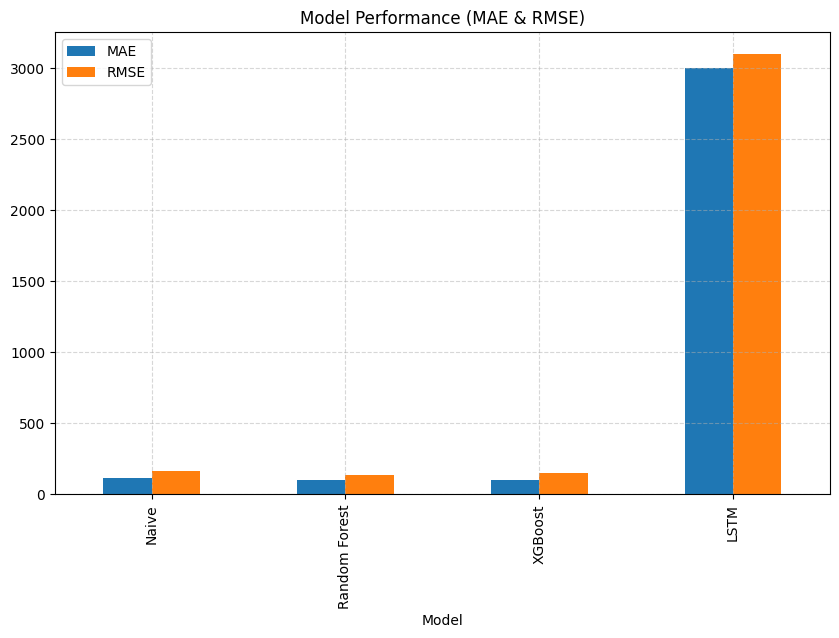

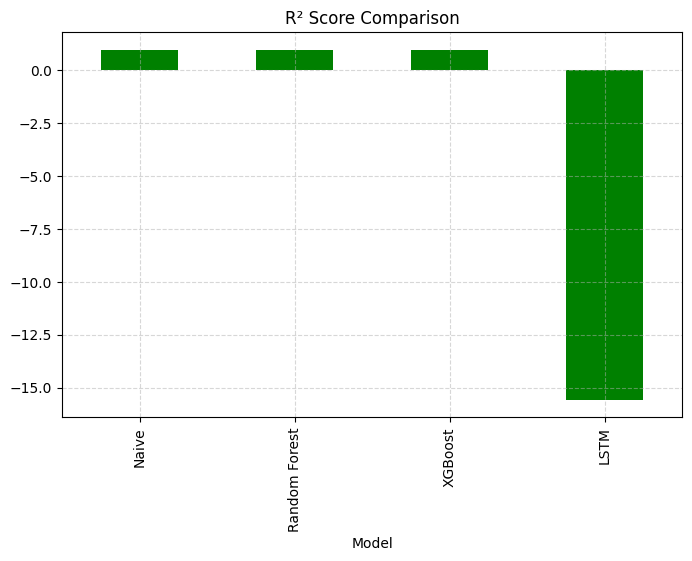

In [39]:
results.set_index('Model')[['MAE','RMSE']].plot(kind='bar', figsize=(10,6), title="Model Performance (MAE & RMSE)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

results.set_index('Model')['R²'].plot(kind='bar', color='green', figsize=(8,5), title="R² Score Comparison")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


C:\Users\abhay\OneDrive\Desktop\Pyhton + AI\Crypto_price_predictor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


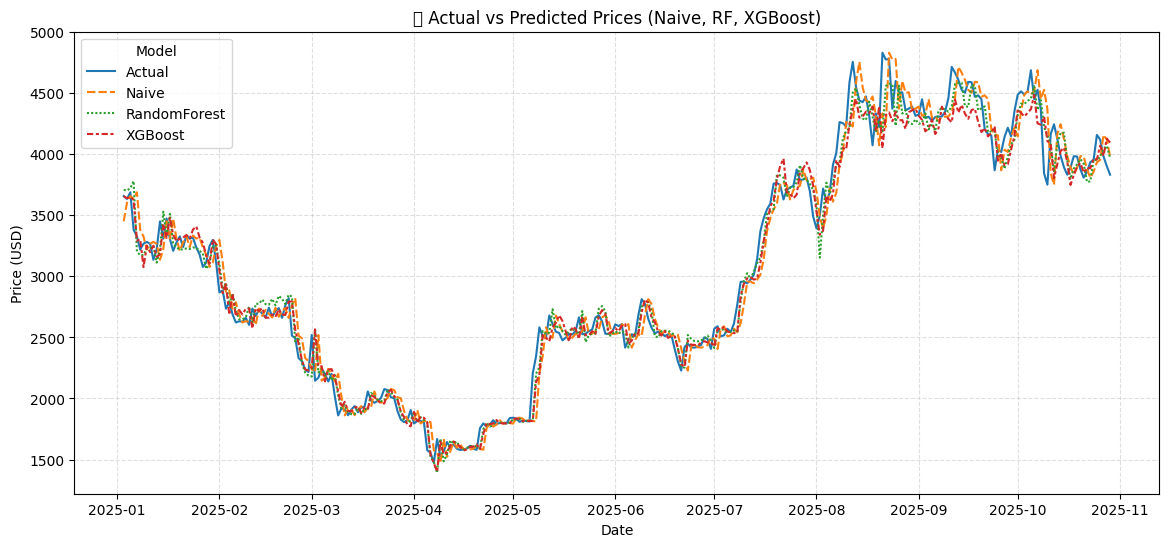

C:\Users\abhay\OneDrive\Desktop\Pyhton + AI\Crypto_price_predictor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


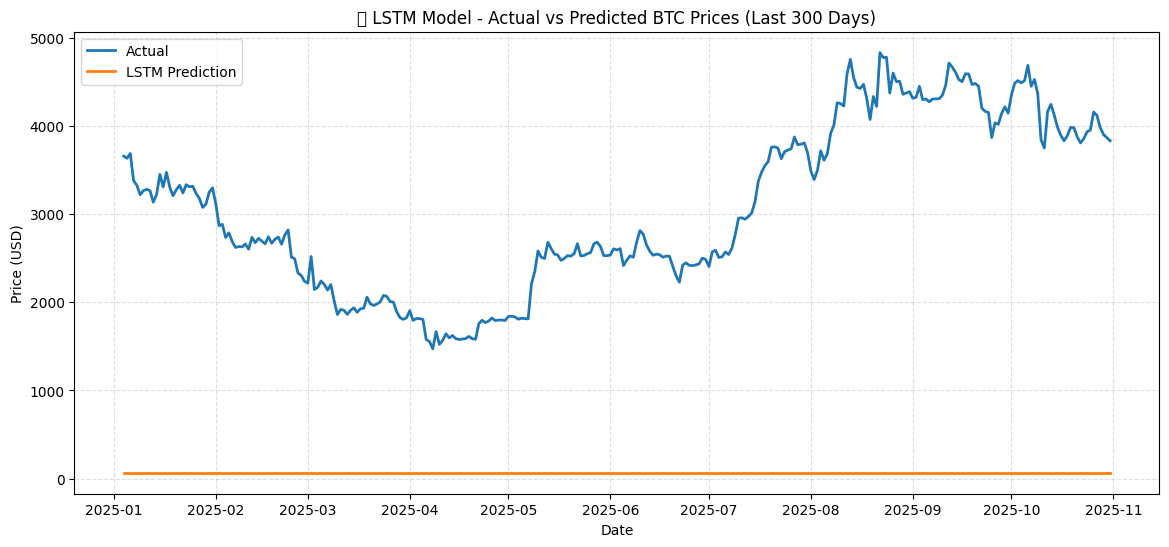

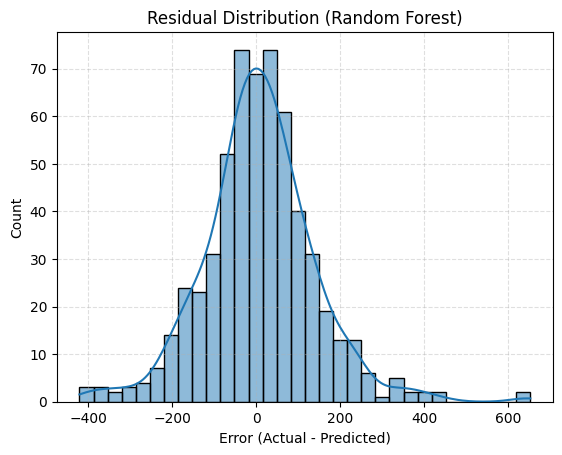

In [40]:
import seaborn as sns

# Create aligned DataFrame for visualization
compare_df = pd.DataFrame({
    "Actual": y_val.values,
    "Naive": y_pred_naive.values,
    "RandomForest": y_pred,
    "XGBoost": y_pred_xgb,
}, index=y_val.index)

# For LSTM (align dates properly)
compare_lstm_df = pd.DataFrame({
    "Actual": y_va,
    "LSTM": y_pred_lstm.flatten()
}, index=coin_df.index[-len(y_va):])

# --- Plot Actual vs Predicted (Last 300 points for clarity) ---
plt.figure(figsize=(14,6))
sns.lineplot(data=compare_df.tail(300))
plt.title("📉 Actual vs Predicted Prices (Naive, RF, XGBoost)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Model")
plt.show()

# --- Plot LSTM separately ---
plt.figure(figsize=(14,6))
sns.lineplot(x=compare_lstm_df.index[-300:], y=compare_lstm_df["Actual"].tail(300), label="Actual", linewidth=2)
sns.lineplot(x=compare_lstm_df.index[-300:], y=compare_lstm_df["LSTM"].tail(300), label="LSTM Prediction", linewidth=2)
plt.title("🧠 LSTM Model - Actual vs Predicted BTC Prices (Last 300 Days)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()

# --- Residual plot (errors) ---
residuals = y_val - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Random Forest)")
plt.xlabel("Error (Actual - Predicted)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


C:\Users\abhay\OneDrive\Desktop\Pyhton + AI\Crypto_price_predictor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


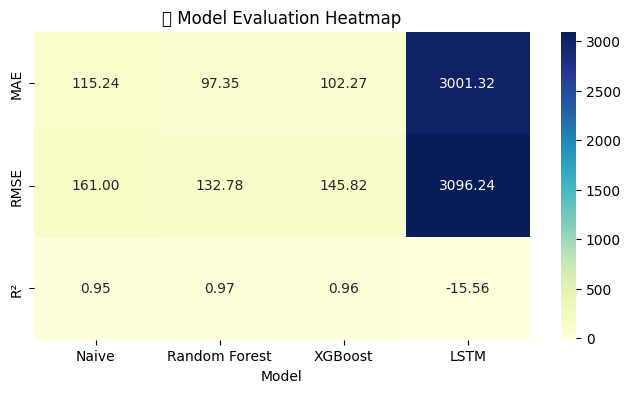

In [41]:
plt.figure(figsize=(8,4))
sns.heatmap(results.set_index("Model")[["MAE","RMSE","R²"]].T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("📊 Model Evaluation Heatmap")
plt.show()
